In [19]:
import geodatasets
import geopandas as gpd
import libpysal
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import math
import numpy as np

In [2]:
geodatasets.data

{'geoda': {'airbnb': {'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.airbnb',
   'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
   'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
   'filename': 'airbnb.zip'},
  'atlanta': {'url': 'https://geodacenter.github.io/data-and-lab//data/atlanta_hom.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.atlanta',
   'description': 'Atlanta, GA region homicide counts and rates',
   'geometry_type': 'Polygon',
   'nrows': 90,
   'ncols': 24,
   'details': 'https://geodacenter.github.io/data-and-lab//atlanta_old/',
   'hash': 'a33a76e12168fe84361e60c88a9df4856730487305846c559715c89b1a2b5e09',
   'filename': 'atlanta_hom.zip',
   'members': ['atlanta_hom/atl_hom.geojson']},
  'cars': {'url': 'https://geodacenter.github.io/data-and-lab//data/Abandoned_Vehicles_Map.csv',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.cars',
   'description': '2011 abandoned vehicles in Chicago (311 complaints).',
   'geometry_type': 'Point',
   'nrows': 137867,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//1-source-and-description/',
   'hash': '6a0b23bc7eda2dcf1af02d43ccf506b24ca8d8c6dc2fe86a2a1cc051b03aae9e',
   'filename': 'Abandoned_Vehicles_Map.csv'},
  'charleston1': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston1',
   'description': '2000 Census Tract Data for Charleston, SC MSA and counties',
   'geometry_type': 'Polygon',
   'nrows': 117,
   'ncols': 31,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston-1_old/',
   'hash': '4a4fa9c8dd4231ae0b2f12f24895b8336bcab0c28c48653a967cffe011f63a7c',
   'filename': 'CharlestonMSA.zip',
   'members': ['CharlestonMSA/sc_final_census2.gpkg']},
  'charleston2': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA2.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston2',
   'description': '1998 and 2001 Zip Code Business Patterns (Census Bureau) for Charleston, SC MSA',
   'geometry_type': 'Polygon',
   'nrows': 42,
   'ncols': 60,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston2/',
   'hash': '056d5d6e236b5bd95f5aee26c77bbe7d61bd07db5aaf72866c2f545205c1d8d7',
   'filename': 'CharlestonMSA2.zip',
   'members': ['CharlestonMSA2/CharlestonMSA2.gpkg']},
  'chicago_health': {'url': 'https://geodacenter.github.io/data-and-lab//data/comarea.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_health',
   'description': 'Chicago Health + Socio-Economics',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 87,
   'details': 'https://geodacenter.github.io/data-and-lab//comarea_vars/',
   'hash': '4e872adb552786eae2fcd745524696e5e4cd33cc9a6c032471c0e75328871401',
   'filename': 'comarea.zip'},
  'chicago_commpop': {'url': 'https://geodacenter.github.io/data-and-lab//data/chicago_commpop.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_commpop',
   'description': 'Chicago Community Area Population Percent Change for 2000 and 2010',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 9,
   'details': 'https://geodacenter.github.io/data-and-lab//commpop/',
   'hash': '1dbebb50c8ea47e2279ea819ef64ba793bdee2b88e4716bd6c6ec0e0d8e0e05b',
   'filename': 'c

# Chicago

In [3]:
chicago = geodatasets.get_path("geoda airbnb")
chicago_gdf = gpd.read_file(chicago)

In [4]:
chicago_g = libpysal.graph.Graph.build_contiguity(chicago_gdf, rook=True)
#chicago_g.to_parquet("graphs/real/chicago/g_true.parquet")

In [5]:
chicago_g.cardinalities.mean()

np.float64(4.64935064935065)

In [6]:
chicago_gdf.columns

Index(['community', 'shape_area', 'shape_len', 'AREAID', 'response_r',
       'accept_r', 'rev_rating', 'price_pp', 'room_type', 'num_spots',
       'poverty', 'crowded', 'dependency', 'without_hs', 'unemployed',
       'income_pc', 'harship_in', 'num_crimes', 'num_theft', 'population',
       'geometry'],
      dtype='str')

In [7]:
chicago_gdf["perc_crimes"] = chicago_gdf['num_crimes']/chicago_gdf["population"]
chicago_gdf["perc_theft"] = chicago_gdf['num_theft']/chicago_gdf["population"]
chicago_gdf

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry,perc_crimes,perc_theft
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844...",0.274866,0.068045
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816...",0.220683,0.052552
2,FULLER PARK,19916704.8692,NaN,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017...",0.613352,0.133171
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165...",0.292581,0.065119
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816...",0.152065,0.036657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,MOUNT GREENWOOD,75584290.0209,48665.1305392,74,NaN,NaN,NaN,NaN,NaN,0,...,4.3,8.7,34381,16,1233,326,19093,"POLYGON ((-87.69646 41.70714, -87.69644 41.706...",0.064579,0.017074
73,MORGAN PARK,91877340.6988,46396.419362,75,85.500000,96.666667,97.000000,67.933333,1.000000,5,...,10.8,15.0,27149,30,3998,912,22544,"POLYGON ((-87.64215 41.68508, -87.64249 41.685...",0.177342,0.040454
74,OHARE,371835607.687,173625.98466,76,83.500000,100.000000,83.000000,38.500000,2.500000,2,...,10.9,7.1,25828,24,3423,1011,12756,"MULTIPOLYGON (((-87.83658 41.9864, -87.83658 4...",0.268344,0.079257
75,EDGEWATER,48449990.8397,31004.8309456,77,94.429530,85.925676,94.540323,77.199510,1.582353,170,...,9.7,9.2,33385,19,4559,1409,56521,"POLYGON ((-87.65456 41.99817, -87.65456 41.998...",0.080660,0.024929


In [8]:
cols_to_plot = ['poverty', 'crowded', 'dependency', 'without_hs', 'unemployed',
       'income_pc', 'harship_in', 'perc_crimes', 'perc_theft']

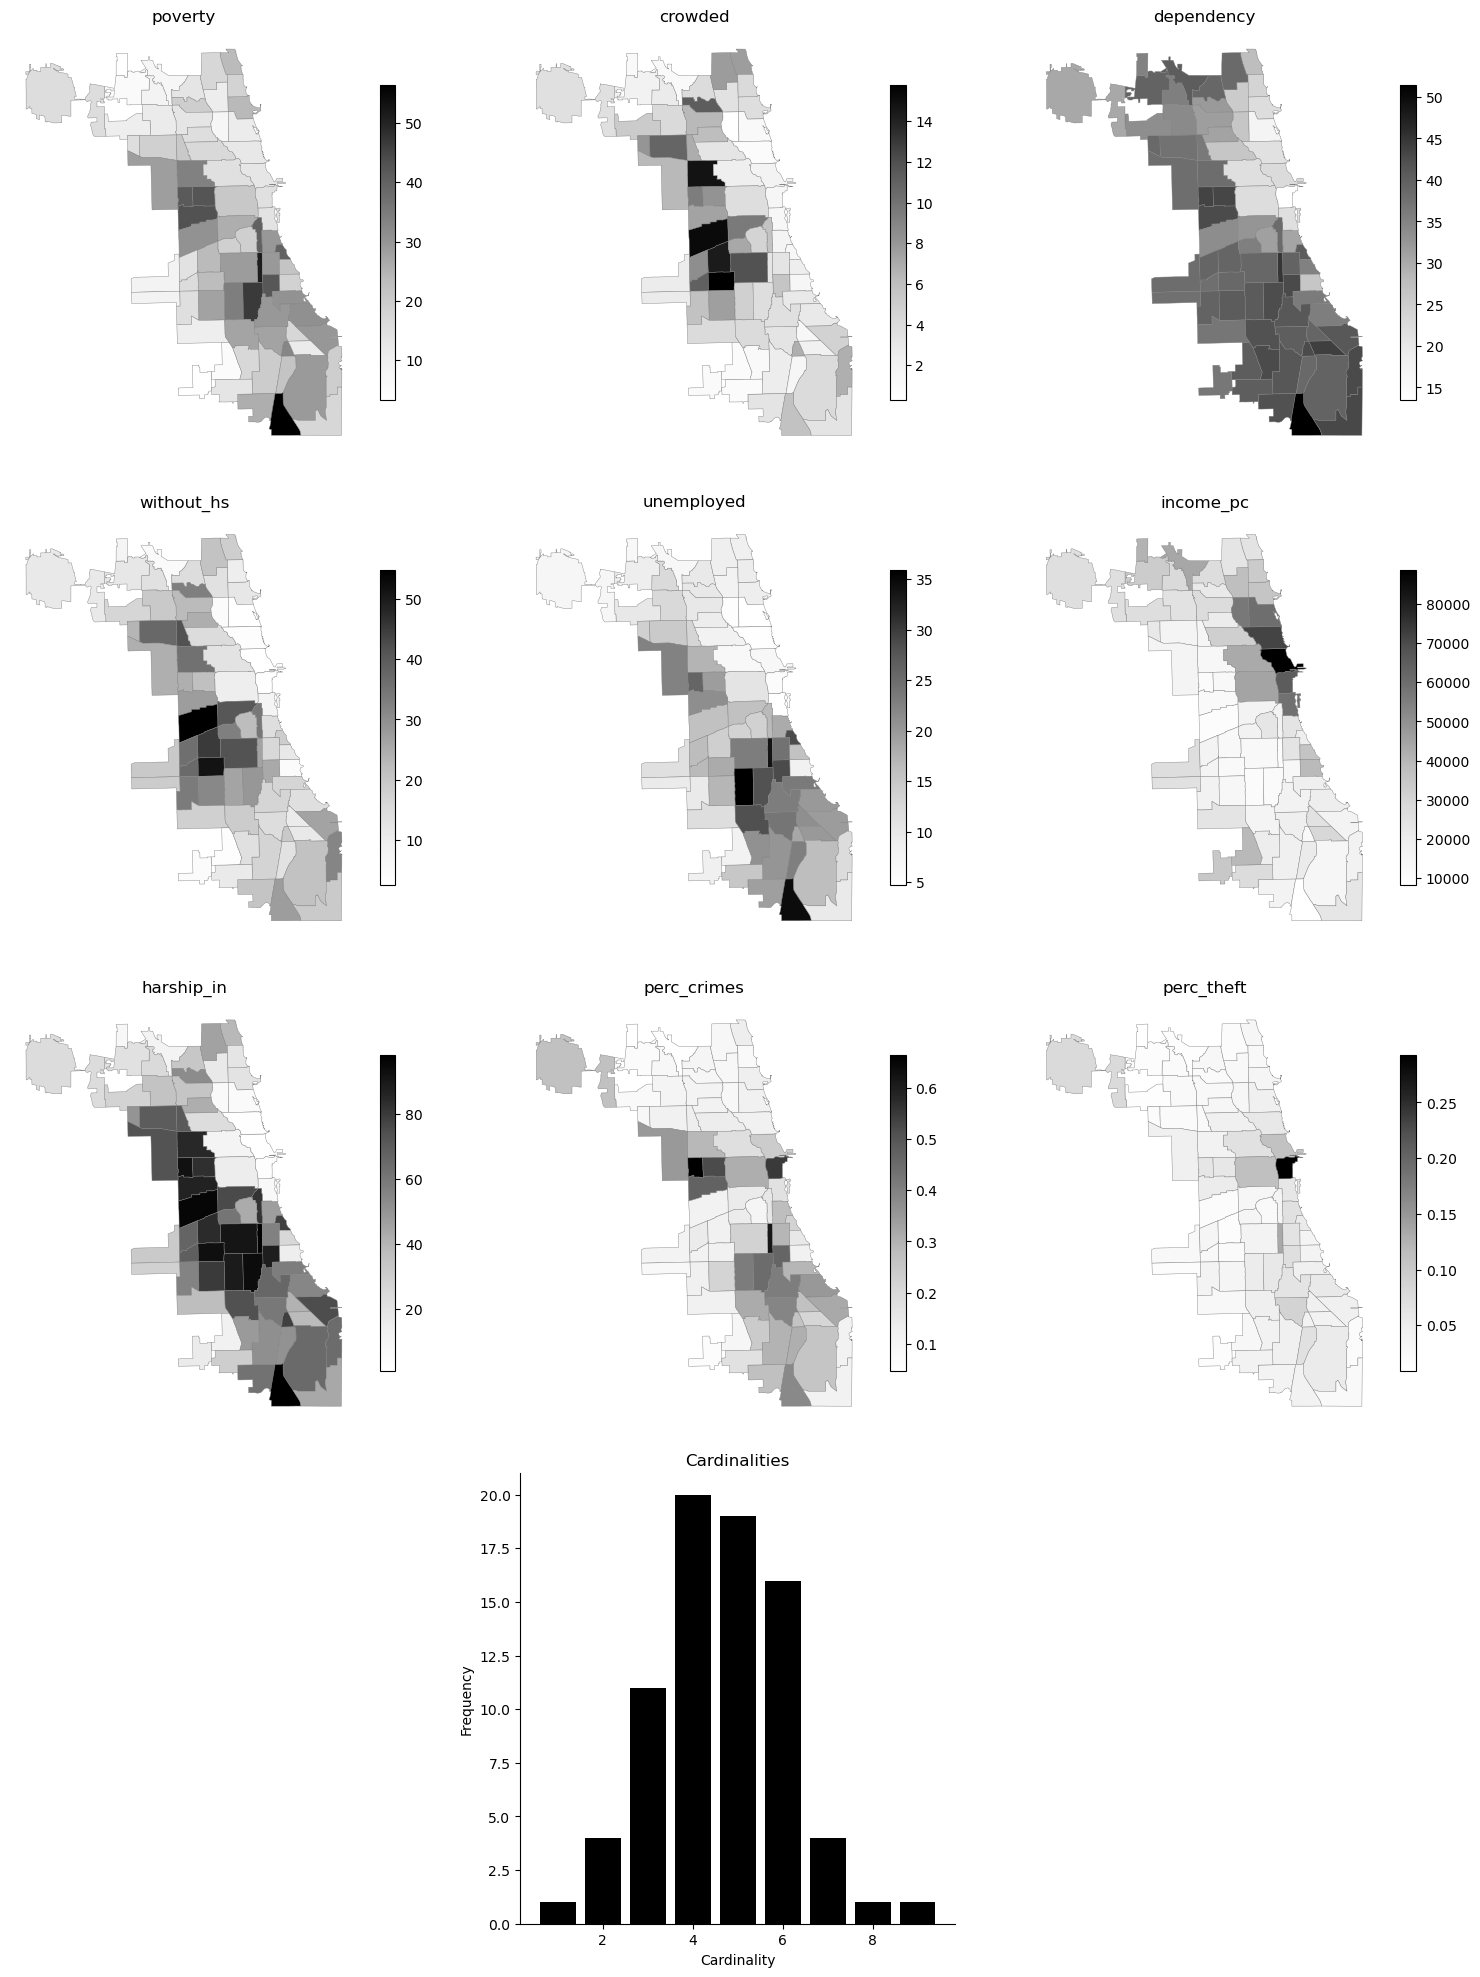

In [9]:
n_cols = 3
n_maps = len(cols_to_plot)

# +1 extra slot reserved for the cardinality plot
n_rows = math.ceil((n_maps + 1) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Index of "4th row, middle column" (0-indexed: row 3, col 1)
card_pos = 3 * n_cols + 1

map_idx = 0
for i in range(len(axes)):
    if i == card_pos:
        continue  # reserved, filled below
    if map_idx < n_maps:
        col = cols_to_plot[map_idx]
        chicago_gdf.plot(
            column=col, ax=axes[i], legend=True, cmap='Greys',
            edgecolor='grey', linewidth=0.3,
            legend_kwds={"shrink": 0.7}
        )
        axes[i].set_title(col)
        axes[i].axis('off')
        map_idx += 1
    else:
        axes[i].axis('off')

# Cardinalities bar chart in the reserved slot
cardinalities = chicago_g.cardinalities  # <- adjust to your graph/W object
counts = cardinalities.value_counts().sort_index()
axes[card_pos].bar(counts.index, counts.values, color='black')
axes[card_pos].set_xlabel('Cardinality')
axes[card_pos].set_ylabel('Frequency')
axes[card_pos].set_title('Cardinalities')
sns.despine(ax=axes[card_pos])

plt.tight_layout()
plt.savefig("figs/chicago_overview.png", dpi=600, bbox_inches="tight")

In [10]:
# Include geometry in your list of columns to keep
cols_to_keep = cols_to_plot + ['geometry']

# Create the subset
chicago_subset = chicago_gdf[cols_to_keep].copy()

chicago_subset.to_parquet("data/real/chicago.parquet")

# Sacramento

In [11]:
sacramento = geodatasets.get_path("geoda sacramento1")
sacramento_gdf = gpd.read_file(sacramento)

In [12]:
sacramento_g = libpysal.graph.Graph.build_contiguity(sacramento_gdf, rook=True)
#sacramento_g.to_parquet("graphs/real/sacramento/g_true.parquet")

In [13]:
sacramento_g

<Graph of 403 nodes and 2128 nonzero edges (1 component, 0 isolates) indexed by
 [0, 1, 2, 3, 4, ...]>

In [14]:
sacramento_gdf.columns

Index(['FIPS', 'MSA', 'TOT_POP', 'POP_16', 'POP_65', 'WHITE_', 'BLACK_',
       'ASIAN_', 'HISP_', 'MULTI_RA', 'MALES', 'FEMALES', 'MALE1664',
       'FEM1664', 'EMPL16', 'EMP_AWAY', 'EMP_HOME', 'EMP_29', 'EMP_30',
       'EMP16_2', 'EMP_MALE', 'EMP_FEM', 'OCC_MAN', 'OCC_OFF1', 'OCC_INFO',
       'HH_INC', 'POV_POP', 'POV_TOT', 'HSG_VAL', 'FIPSNO', 'POLYID',
       'geometry'],
      dtype='str')

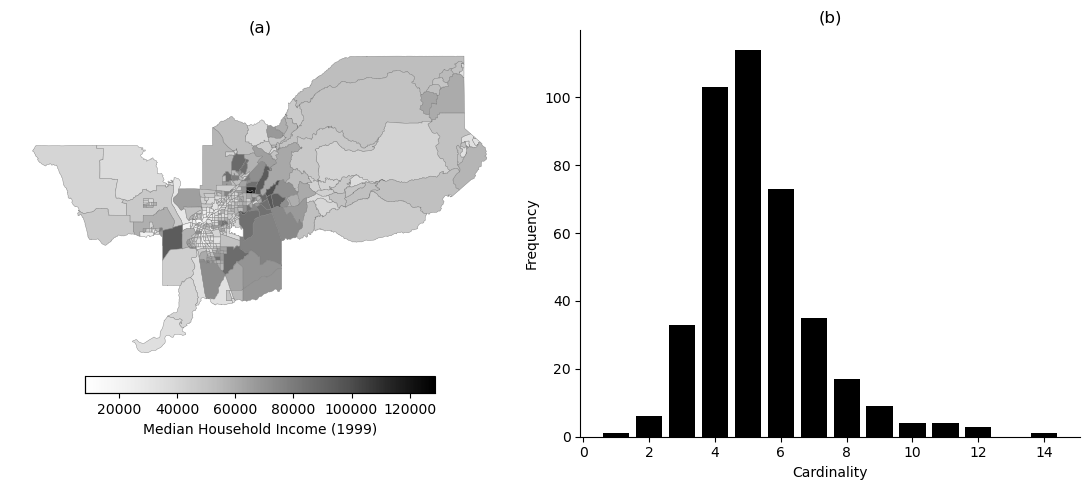

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: Donatns choropleth in grayscale
sacramento_gdf.plot(column="HH_INC", ax=axes[0], legend=True, cmap="Greys",
                 edgecolor="grey", linewidth=0.3,legend_kwds={"location": "bottom", "shrink": 0.7, "pad": 0.02,
                 "label": "Median Household Income (1999)"})


axes[0].set_axis_off()
axes[0].set_title("(a)")

# Right: cardinalities of the Rook contiguity graph
cardinalities = sacramento_g.cardinalities
counts = cardinalities.value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="black")
axes[1].set_xlabel("Cardinality")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b)")

sns.despine()
plt.tight_layout()
plt.savefig("figs/sacramento_overview.png",dpi=600,bbox_inches="tight")

In [16]:
cardinalities.mean()

np.float64(5.280397022332506)

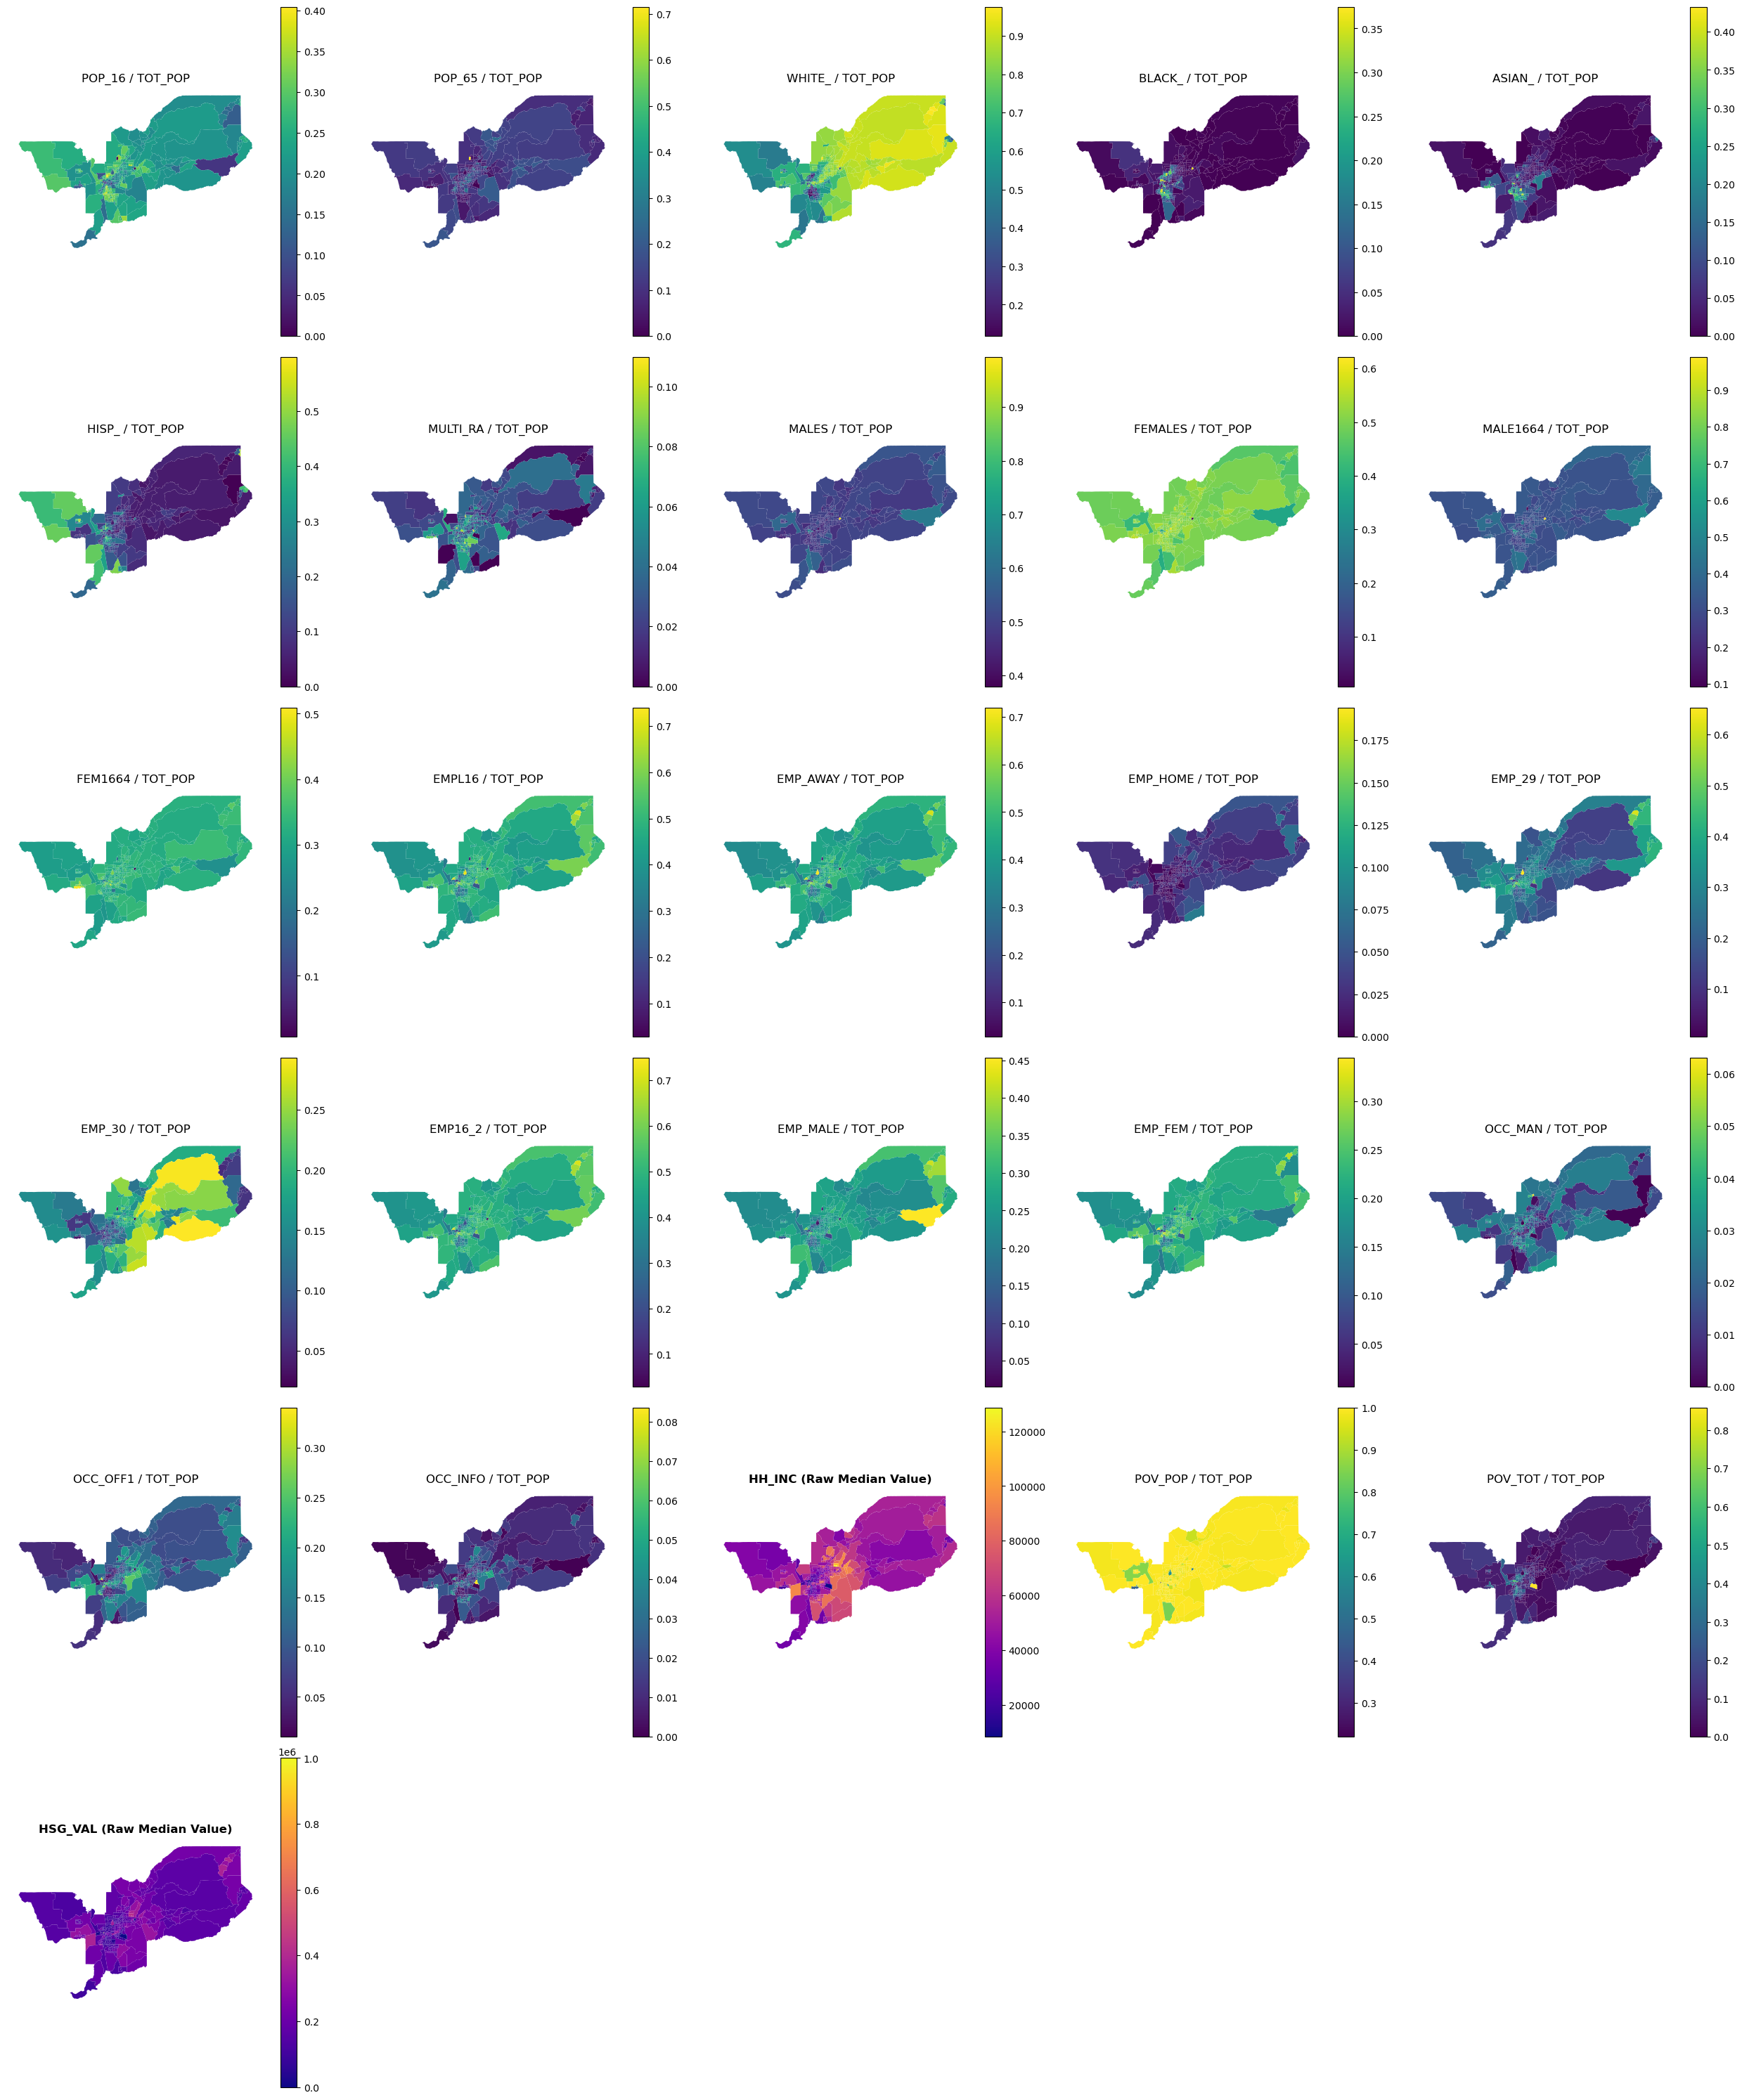

In [20]:
# 1. Identify the start and end columns
all_cols = sacramento_gdf.columns.to_list()
start_idx = all_cols.index('POP_16')
end_idx = all_cols.index('HSG_VAL') + 1 

cols_to_plot = all_cols[start_idx:end_idx]
num_plots = len(cols_to_plot)

# 2. Set up a dynamically sized grid for the subplots
cols = 5
rows = math.ceil(num_plots / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(25, 5 * rows))
axes = axes.flatten()

# Specify the columns to plot directly
raw_plot_cols = ['HH_INC', 'HSG_VAL']

# 3. Loop through the columns and conditionally plot
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    if col in raw_plot_cols:
        # Plot RAW values for Income and Housing Value
        sacramento_gdf[col] = sacramento_gdf[col].astype(float) # Ensure it's a number
        
        sacramento_gdf.plot(
            column=col, 
            ax=ax, 
            cmap='plasma', # Using a different colormap just to easily distinguish raw vs ratios visually
            legend=True, 
            missing_kwds={'color': 'lightgrey'} 
        )
        ax.set_title(f'{col} (Raw Median Value)', fontsize=12, fontweight='bold')
        
    else:
        # Plot NORMALIZED values for all other demographic counts
        # Divide by TOT_POP. Replace 0 with NaN to avoid division by zero errors
        normalized_values = sacramento_gdf[col].astype(float) / sacramento_gdf['TOT_POP'].astype(float).replace(0, np.nan)
        
        # Assign the calculated values to a temporary column for plotting
        sacramento_gdf['temp_norm_val'] = normalized_values
        
        # Plot the choropleth map
        sacramento_gdf.plot(
            column='temp_norm_val', 
            ax=ax, 
            cmap='viridis',      
            legend=True, 
            missing_kwds={'color': 'lightgrey'} 
        )
        ax.set_title(f'{col} / TOT_POP', fontsize=12)
        
    # Remove axis borders for a cleaner look
    ax.axis('off')

# 4. Hide the extra/empty subplots in the grid
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# 5. Finalize layout and display
plt.tight_layout()

In [32]:
sacramento_gdf[['HH_INC', 'geometry']].to_parquet("data/real/sacramento.parquet")

# Ceara

In [22]:
ceara_zika_gdf = gpd.read_file("https://geodacenter.github.io/data-and-lab/data/ceara.zip")

In [23]:
ceara_zika_g = libpysal.graph.Graph.build_contiguity(ceara_zika_gdf, rook=True)
#ceara_zika_g.to_parquet("graphs/real/ceara_zika/g_true.parquet")

In [24]:
ceara_zika_g.cardinalities.mean()

np.float64(5.086956521739131)

In [25]:
cols_to_plot = ['mobility', 'environ',
       'housing', 'sanitation', 'infra']

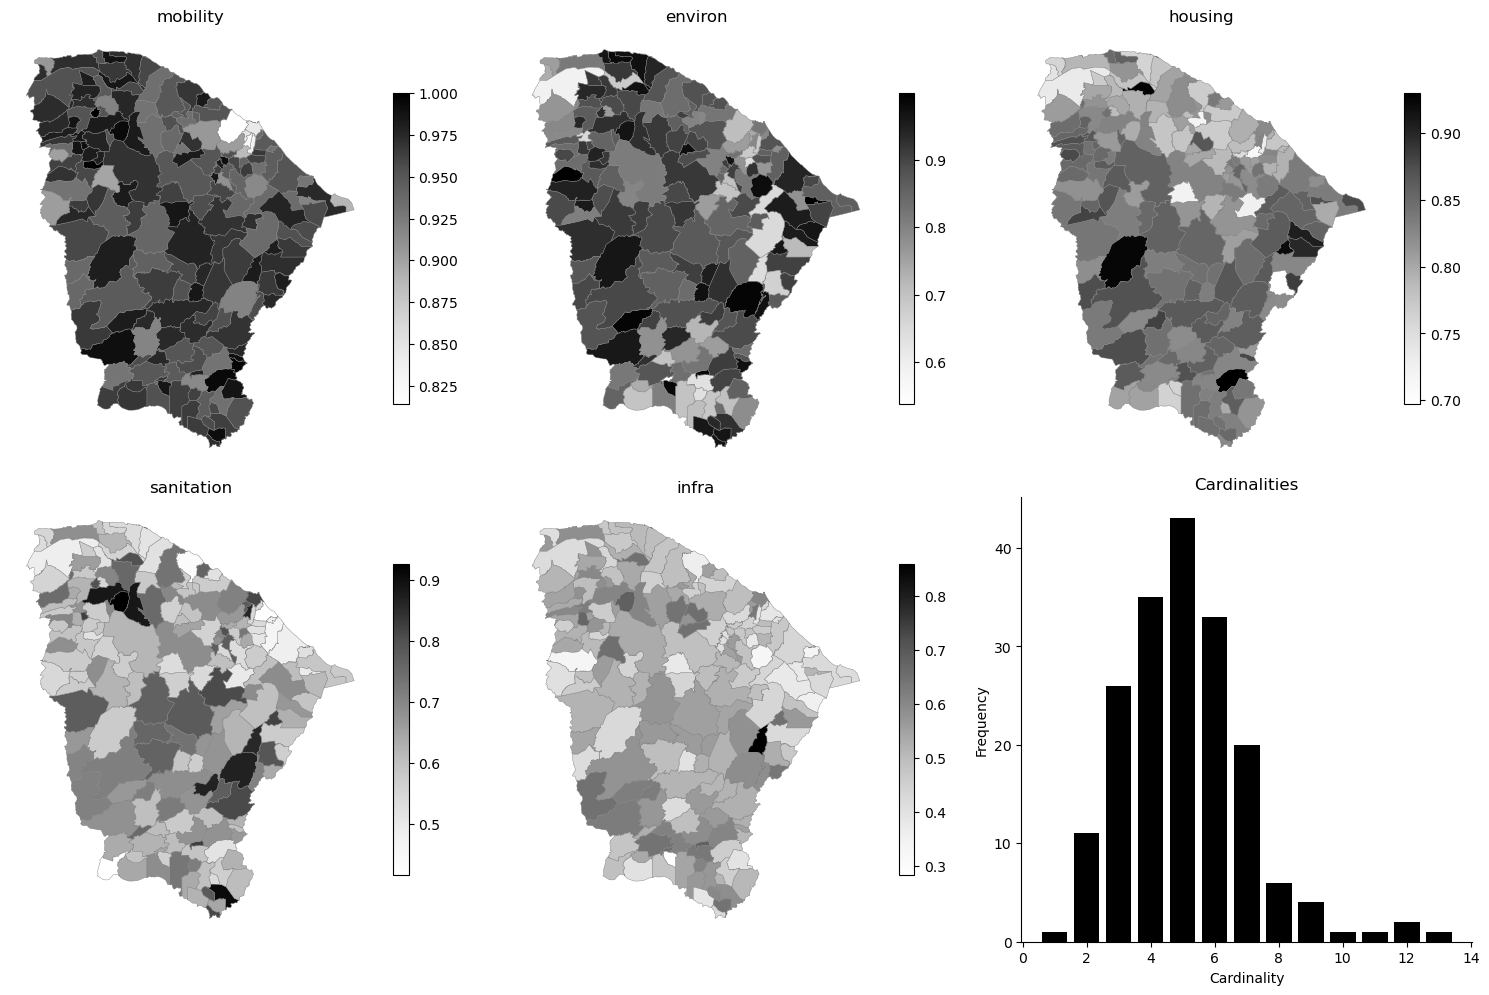

In [26]:
n_cols = 3
n_maps = len(cols_to_plot)

# +1 extra slot reserved for the cardinality plot
n_rows = math.ceil((n_maps + 1) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# 6th spot, 0-indexed = index 5
card_pos = 5

map_idx = 0
for i in range(len(axes)):
    if i == card_pos:
        continue  # reserved, filled below
    if map_idx < n_maps:
        col = cols_to_plot[map_idx]
        ceara_zika_gdf.plot(
            column=col, ax=axes[i], legend=True, cmap='Greys',
            edgecolor='grey', linewidth=0.3,
            legend_kwds={"shrink": 0.7}
        )
        axes[i].set_title(col)
        axes[i].axis('off')
        map_idx += 1
    else:
        axes[i].axis('off')

# Cardinalities bar chart in the reserved slot
cardinalities = ceara_zika_g.cardinalities  # <- adjust to your graph/W object
counts = cardinalities.value_counts().sort_index()
axes[card_pos].bar(counts.index, counts.values, color='black')
axes[card_pos].set_xlabel('Cardinality')
axes[card_pos].set_ylabel('Frequency')
axes[card_pos].set_title('Cardinalities')
sns.despine(ax=axes[card_pos])

plt.tight_layout()
plt.savefig("figs/ceara_zika_overview.png", dpi=600, bbox_inches="tight")

In [38]:
ceara_zika_gdf[['mobility', 'environ',
       'housing', 'sanitation', 'infra', 'geometry']].to_parquet("data/real/ceara_zika.parquet")

# Guerry

In [27]:
guerry = geodatasets.get_path("geoda guerry")
guerry_gdf = gpd.read_file(guerry)

In [3]:
guerry_g = libpysal.graph.Graph.build_contiguity(guerry_gdf, rook=True)
#guerry_g.to_parquet("graphs/real/guerry/g_true.parquet")

In [5]:
guerry_g.cardinalities.mean()

np.float64(4.9411764705882355)

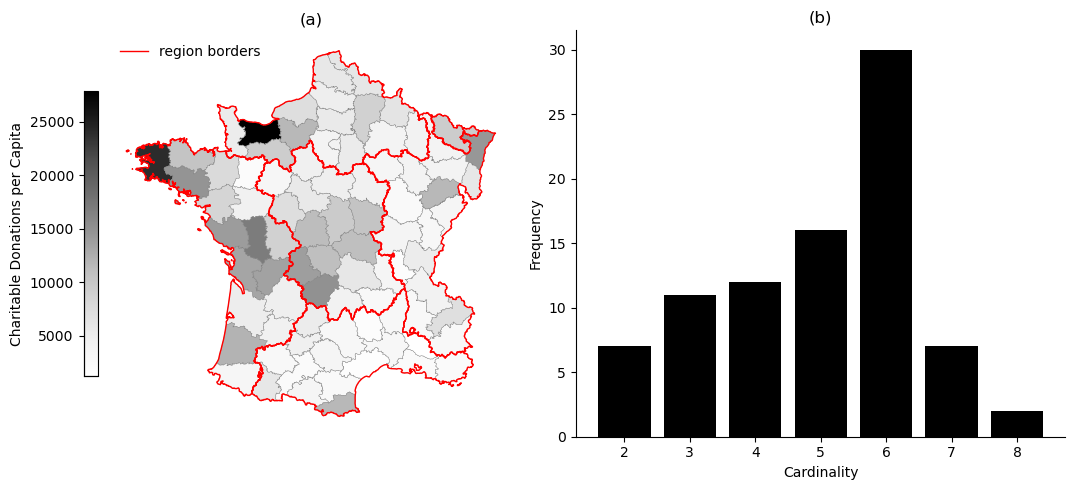

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: Donatns choropleth in grayscale
guerry_gdf.plot(column="Donatns", ax=axes[0], legend=True, cmap="Greys",
                 edgecolor="grey", linewidth=0.3,legend_kwds={"location": "left", "shrink": 0.7, "pad": 0.02,
                 "label": "Charitable Donations per Capita"})

# Highlight the historical Regions with a red outline
regions = guerry_gdf.dissolve(by="Region")
regions.boundary.plot(ax=axes[0], color="red", linewidth=1)

axes[0].set_axis_off()
axes[0].set_title("(a)")

region_handle = Line2D([0], [0], color="red", linewidth=1, label="region borders")
axes[0].legend(handles=[region_handle], loc="upper left", frameon=False)

# Right: cardinalities of the Rook contiguity graph
cardinalities = guerry_g.cardinalities
counts = cardinalities.value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="black")
axes[1].set_xlabel("Cardinality")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b)")

sns.despine()
plt.tight_layout()
plt.savefig("figs/guerry_overview.png",dpi=600,bbox_inches="tight")

In [8]:
guerry_gdf[["Donatns","Region","geometry"]].to_parquet("data/real/guerry.parquet")

# Elections

In [8]:
# 1. load original, drop isolates, reset index
elections_data = libpysal.examples.load_example('Elections')
elections_gdf  = gpd.read_file(elections_data.get_path('election.shp'))

In [9]:
elections_g    = libpysal.graph.Graph.build_contiguity(elections_gdf, rook=True)
isolates       = elections_g.isolates

In [10]:
elections_gdf  = (
    elections_gdf
    .drop(index=isolates)
    .reset_index(drop=True)   # clean 0-N index
)

In [32]:
elections_gdf.loc[isolates]

,STATEFP,COUNTYFP,GEOID,ALAND,AWATER,area_name,state_abbr,PST045214,PST040210,PST120214,...,total_2012,Demvotes12,GOPvotes12,county_fip,state_fips,pct_dem_12,pct_gop_12,diff_2012,pct_pt_12,geometry
focal,,,,,,,,,,,,,,,,,,,,,
1267,25,021,25021,1.025928e+09,124925285.0,Norfolk County,MA,692254.0,670743.0,3.2,...,350195.0,200891.0,144654.0,21.0,25.0,0.573655,0.413067,56237.0,0.160588,"MULTIPOLYGON (((-70.845 42.242, -70.841 42.243..."
2729,39,049,39049,1.378859e+09,29120125.0,Franklin County,OH,1231393.0,1163543.0,5.8,...,541751.0,325654.0,207941.0,49.0,39.0,0.601114,0.383831,117713.0,0.217282,"POLYGON ((-83.261 40.003, -83.259 40.005, -83...."
2763,54,029,54029,2.139571e+08,13879330.0,Hancock County,WV,30112.0,30675.0,-1.8,...,11991.0,4571.0,7159.0,29.0,54.0,0.381203,0.597031,2588.0,-0.215829,"POLYGON ((-80.668 40.582, -80.666 40.588, -80...."


In [11]:
# 2. rebuild true graph FROM the clean gdf so ids match 0-N
g_true = libpysal.graph.Graph.build_contiguity(elections_gdf, rook=True)

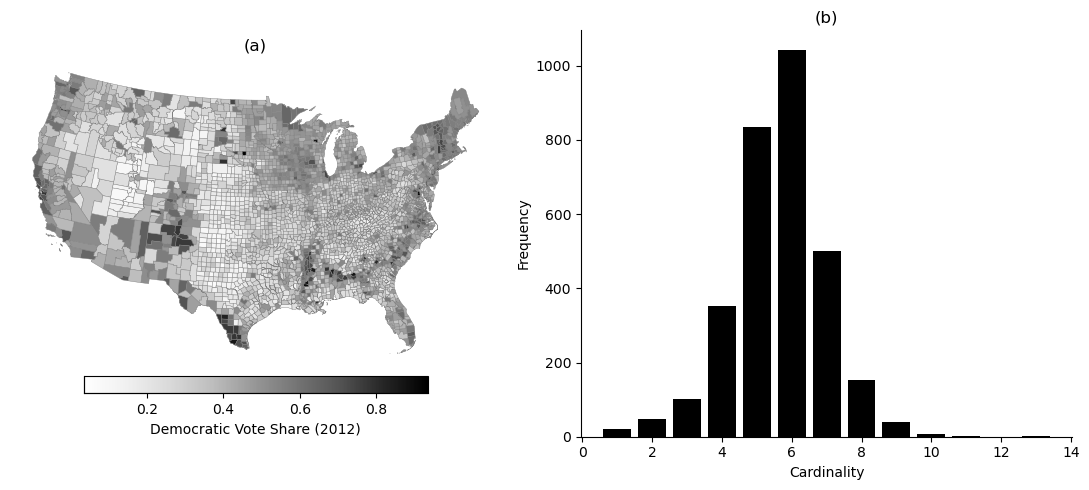

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: Donatns choropleth in grayscale
elections_gdf.set_crs("epsg:4326", allow_override=True).to_crs("ESRI:102003").plot(column="pct_dem_12", ax=axes[0], legend=True, cmap="Greys",
                 edgecolor="grey", linewidth=0.3,legend_kwds={"location": "bottom", "shrink": 0.7, "pad": 0.02,
                 "label": "Democratic Vote Share (2012)"})


axes[0].set_axis_off()
axes[0].set_title("(a)")

# Right: cardinalities of the Rook contiguity graph
cardinalities = g_true.cardinalities
counts = cardinalities.value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="black")
axes[1].set_xlabel("Cardinality")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b)")

sns.despine()
plt.tight_layout()
plt.savefig("figs/elections_overview.png",dpi=600,bbox_inches="tight")

In [14]:
g_true

<Graph of 3105 nodes and 17472 nonzero edges (1 component, 0 isolates) indexed by
 [0, 1, 2, 3, 4, ...]>

In [16]:
# 3. save both
g_true.to_parquet("graphs/real/elections/g_true.parquet")
elections_gdf[["state_abbr", "pct_dem_12", "geometry","region"]].to_parquet(
    "data/real/elections.parquet"
)

# South

In [34]:
south = geodatasets.get_path("geoda south")
south_gdf = gpd.read_file(south)

In [35]:
south_g = libpysal.graph.Graph.build_contiguity(south_gdf, rook=True)
#south_g.to_parquet("graphs/real/south/g_true.parquet")

In [18]:
south_g.cardinalities.mean()

np.float64(5.453257790368272)

In [21]:
south_gdf["STATE_FIPS"].unique()

<ArrowStringArray>
['54', '10', '24', '51', '21', '11', '40', '47', '37', '48', '05', '45', '01',
 '28', '13', '22', '12']
Length: 17, dtype: str

<Axes: >

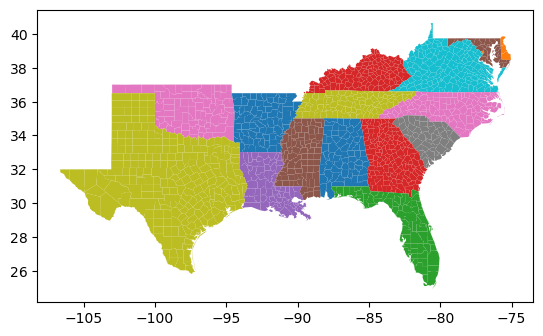

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: Donatns choropleth in grayscale
south_gdf.plot(column="Donatns", ax=axes[0], legend=True, cmap="Greys",
                 edgecolor="grey", linewidth=0.3)

# Highlight the historical Regions with a red outline
regions = guerry_gdf.dissolve(by="Region")
regions.boundary.plot(ax=axes[0], color="red", linewidth=1)

axes[0].set_axis_off()
axes[0].set_title("(a)")

region_handle = Line2D([0], [0], color="red", linewidth=1, label="region borders")
axes[0].legend(handles=[region_handle], loc="lower left", frameon=False)

# Right: cardinalities of the Rook contiguity graph
cardinalities = guerry_g.cardinalities
counts = cardinalities.value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="black")
axes[1].set_xlabel("Cardinality")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b)")

sns.despine()
plt.tight_layout()
plt.savefig("figs/guerry_overview.png",dpi=600,bbox_inches="tight")

In [37]:
cols_to_plot = ["HR90","UE90","DV90","FP89","BLK90"]

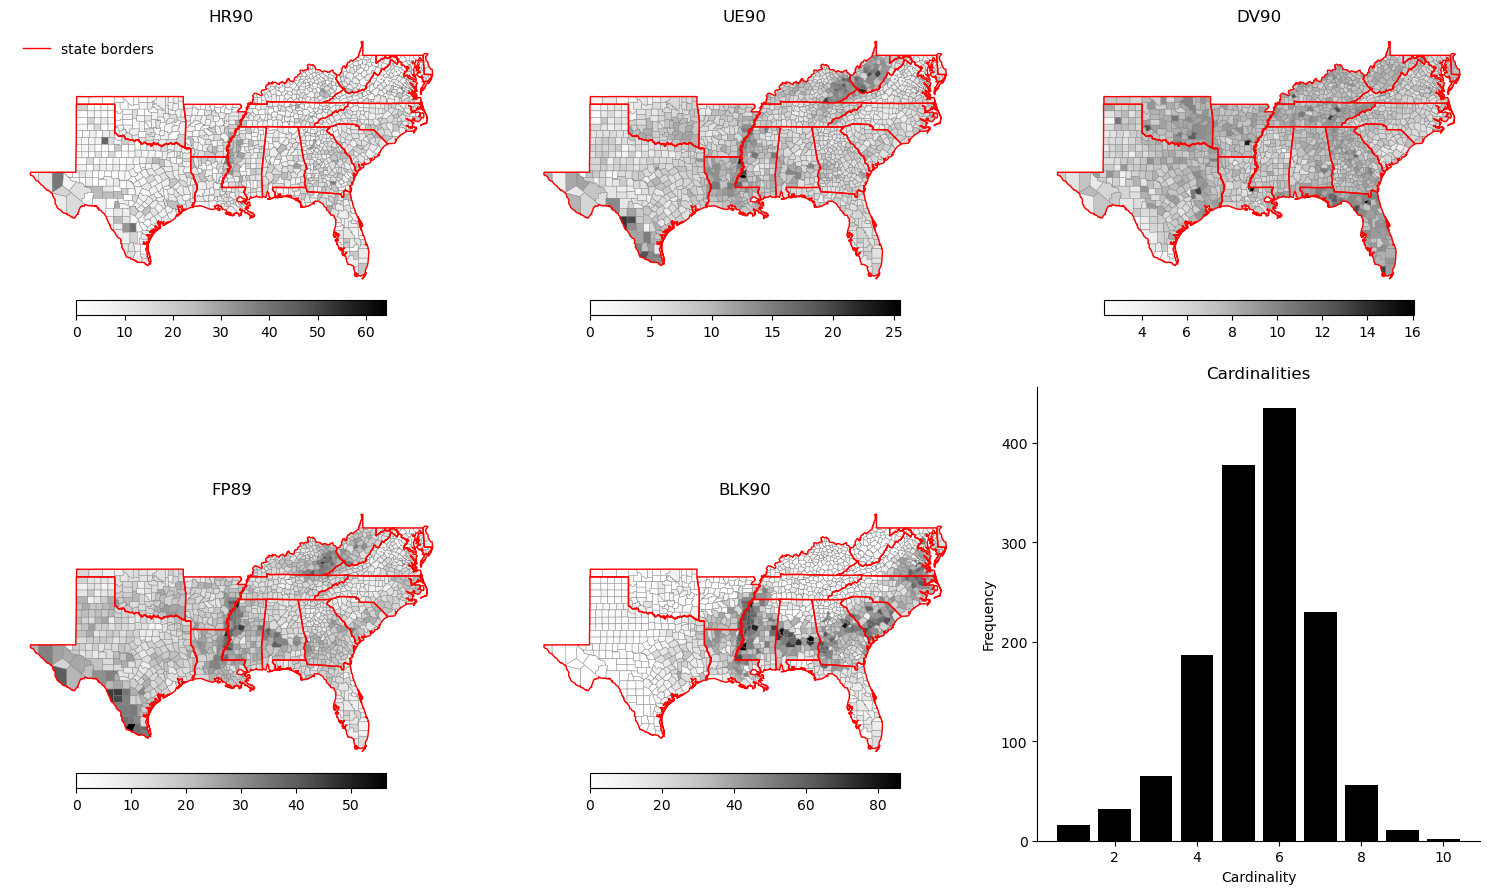

In [41]:
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

n_cols = 3
n_maps = len(cols_to_plot)

# +1 extra slot reserved for the cardinality plot
n_rows = math.ceil((n_maps + 1) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Dissolve once, reuse for every map
states = south_gdf.dissolve(by="STATE_FIPS")

for i, col in enumerate(cols_to_plot):
    south_gdf.plot(
        column=col, ax=axes[i], legend=True, cmap='Greys', edgecolor='grey',
        linewidth=0.3,
        legend_kwds={"location": "bottom", "shrink": 0.7, "pad": 0.02}
    )
    # Red state outlines
    states.boundary.plot(ax=axes[i], color="red", linewidth=1)

    axes[i].set_title(col)
    axes[i].axis('off')

# Add a single "state borders" legend entry to the first map only
state_handle = mlines.Line2D([0], [0], color="red", linewidth=1, label="state borders")
axes[0].legend(handles=[state_handle], loc="upper left", frameon=False)

# Cardinalities bar chart in the next open slot
card_pos = n_maps
cardinalities = south_g.cardinalities  # <- adjust to your graph/W object
counts = cardinalities.value_counts().sort_index()
axes[card_pos].bar(counts.index, counts.values, color='black')
axes[card_pos].set_xlabel('Cardinality')
axes[card_pos].set_ylabel('Frequency')
axes[card_pos].set_title('Cardinalities')
sns.despine(ax=axes[card_pos])

# Hide any remaining unused subplots
for j in range(card_pos + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("figs/south_overview.png",dpi=600,bbox_inches="tight")

In [64]:
south_gdf[["HR90","UE90","DV90","FP89","BLK90","STATE_FIPS","geometry"]].to_parquet("data/real/south.parquet")